# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP
## Level 1: Tasks 1, 2 and 3
### Dataset: Zomato Restaurant Dataset

This notebook performs:
1. **Task 1:** Data Exploration and Preprocessing
2. **Task 2:** Descriptive Analysis
3. **Task 3:** Geospatial Analysis

## 1. Import Libraries



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


try:
    import folium
except ImportError:
    folium = None

from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load Dataset

In [ ]:

BASE_DIR = Path.cwd()
FILE = BASE_DIR / 'Dataset.csv'

df = pd.read_csv(FILE)

print('=' * 60)
print('DATASET LOADED')
print('=' * 60)
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())

DATASET LOADED
Rows and columns: (200, 19)

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate Rating', 'Rating color', 'Rating text', 'Votes']

First 5 rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate Rating,Rating color,Rating text,Votes
0,100001,Restaurant 1,1,New Delhi,Sample Address 1,Sector 18,85.005256,21.579659,Bakery,2165,Indian Rupees(Rs.),Yes,Yes,No,2,3.6,Green,Good,1982
1,100002,Restaurant 2,1,Pune,Sample Address 2,Mall Road,88.057675,27.868107,Fast Food,755,Indian Rupees(Rs.),No,Yes,Yes,1,3.6,Green,Good,1112
2,100003,Restaurant 3,1,Kolkata,Sample Address 3,Sector 18,80.661637,26.469199,Bakery,889,Indian Rupees(Rs.),No,Yes,Yes,1,4.4,Green,Good,2472
3,100004,Restaurant 4,1,Mumbai,Sample Address 4,Main Market,75.059191,19.628002,Cafe,941,Indian Rupees(Rs.),Yes,Yes,Yes,2,4.1,Green,Good,157
4,100005,Restaurant 5,1,Mumbai,Sample Address 5,Sector 18,73.018800,28.669754,Mughlai,607,Indian Rupees(Rs.),Yes,Yes,No,2,2.1,Green,Good,430


## 3. Standardize Column Names

In [8]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(' ', '_')
      .str.replace('/', '_')
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
)

print('Standardized column names:')
print(df.columns.tolist())

Standardized column names:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Price_range', 'Aggregate_Rating', 'Rating_color', 'Rating_text', 'Votes']


# TASK 1: DATA EXPLORATION AND PREPROCESSING

In [9]:
print('=' * 60)
print('LEVEL 1 - TASK 1: DATA EXPLORATION AND PREPROCESSING')
print('=' * 60)

print('\nShape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('Missing_Values'))

LEVEL 1 - TASK 1: DATA EXPLORATION AND PREPROCESSING

Shape: (200, 19)

Data types:
Restaurant_ID             int64
Restaurant_Name             str
Country_Code              int64
City                        str
Address                     str
Locality                    str
Longitude               float64
Latitude                float64
Cuisines                    str
Average_Cost_for_two      int64
Currency                    str
Has_Table_booking           str
Has_Online_delivery         str
Is_delivering_now           str
Price_range               int64
Aggregate_Rating        float64
Rating_color                str
Rating_text                 str
Votes                     int64
dtype: object

Missing values:


,Missing_Values
Restaurant_ID,0
Restaurant_Name,0
Country_Code,0
City,0
Address,0
Locality,0
Longitude,0
Latitude,0
Cuisines,0
Average_Cost_for_two,0


### 4. Convert Common Numeric Columns

In [10]:
numeric_candidates = [
    'Aggregate_rating', 'Votes', 'Price_range',
    'Latitude', 'Longitude', 'Country_Code'
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion completed.')

Numeric conversion completed.


### 5. Remove Duplicate Rows

In [11]:
before = len(df)
df = df.drop_duplicates().copy()
print(f'Duplicate rows removed: {before - len(df)}')
print('Rows after removing duplicates:', len(df))

Duplicate rows removed: 0
Rows after removing duplicates: 200


### 6. Handle Missing Values

In [12]:
# Numeric columns -> median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical columns -> mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode = df[col].mode()
        if len(mode) > 0:
            df[col] = df[col].fillna(mode.iloc[0])

print('Missing values after preprocessing:')
display(df.isnull().sum().sort_values(ascending=False).head(15).to_frame('Missing_Values'))

Missing values after preprocessing:


C:\Windows\Temp\ipykernel_6288\2302611679.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Missing_Values
Restaurant_ID,0
Restaurant_Name,0
Country_Code,0
City,0
Address,0
Locality,0
Longitude,0
Latitude,0
Cuisines,0
Average_Cost_for_two,0


### 7. Aggregate Rating Distribution

In [13]:
if 'Aggregate_rating' in df.columns:
    print('Aggregate rating statistics:')
    display(df['Aggregate_rating'].describe().to_frame())

    plt.figure(figsize=(8, 5))
    sns.histplot(df['Aggregate_rating'], bins=20, kde=True)
    plt.title('Distribution of Aggregate Restaurant Ratings')
    plt.xlabel('Aggregate Rating')
    plt.ylabel('Number of Restaurants')
    plt.tight_layout()
    plt.show()

### 8. Rating Group Distribution

In [14]:
if 'Aggregate_rating' in df.columns:
    bins = [-0.01, 2, 3, 4, 5]
    labels = ['0-2', '2-3', '3-4', '4-5']
    rating_groups = pd.cut(df['Aggregate_rating'], bins=bins, labels=labels)

    print('Rating group distribution:')
    display(rating_groups.value_counts().sort_index().to_frame('Count'))

    print('Rating group percentage:')
    display((rating_groups.value_counts(normalize=True).sort_index() * 100).round(2).to_frame('Percentage'))

# TASK 2: DESCRIPTIVE ANALYSIS

In [15]:
print('=' * 60)
print('LEVEL 1 - TASK 2: DESCRIPTIVE ANALYSIS')
print('=' * 60)

print('\nNumerical descriptive statistics:')
display(df.describe(include=[np.number]).T)

LEVEL 1 - TASK 2: DESCRIPTIVE ANALYSIS

Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Restaurant_ID,200.0,100100.500000,57.879185,100001.000000,100050.750000,100100.500000,100150.250000,100200.000000
Country_Code,200.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Longitude,200.0,80.637804,4.527797,72.993152,76.516571,80.735221,84.834409,88.290115
Latitude,200.0,23.547643,2.981456,18.555384,20.856582,23.647545,26.081828,28.690868
Average_Cost_for_two,200.0,1272.840000,678.413620,202.000000,729.000000,1245.500000,1872.250000,2488.000000
Price_range,200.0,2.375000,1.153703,1.000000,1.000000,2.000000,3.000000,4.000000
Aggregate_Rating,200.0,3.410500,0.843384,2.000000,2.600000,3.400000,4.125000,4.900000
Votes,200.0,1287.235000,720.953124,43.000000,598.250000,1282.000000,1926.000000,2487.000000


### 9. Mean, Median and Standard Deviation

In [16]:
num_cols = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std()
}).sort_index()

display(summary)

,Mean,Median,Std_Dev
Aggregate_Rating,3.410500,3.400000,0.843384
Average_Cost_for_two,1272.840000,1245.500000,678.413620
Country_Code,1.000000,1.000000,0.000000
Latitude,23.547643,23.647545,2.981456
Longitude,80.637804,80.735221,4.527797
Price_range,2.375000,2.000000,1.153703
Restaurant_ID,100100.500000,100100.500000,57.879185
Votes,1287.235000,1282.000000,720.953124


### 10. Country Analysis

In [17]:
if 'Country_Code' in df.columns:
    print('Top countries by number of restaurants:')
    display(df['Country_Code'].value_counts().head(10).to_frame('Restaurant_Count'))

Top countries by number of restaurants:


,Restaurant_Count
Country_Code,
1,200


### 11. City Analysis

Top 10 cities by number of restaurants:


,Restaurant_Count
City,
Pune,33
Mumbai,31
Kolkata,30
Gurgaon,24
New Delhi,22
Noida,22
Bengaluru,20
Hyderabad,18


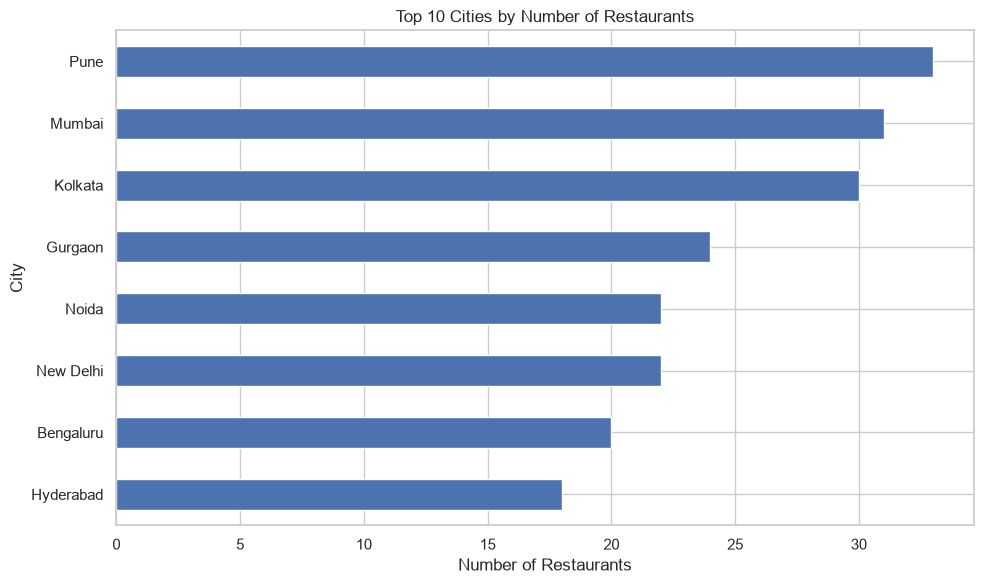

In [18]:
if 'City' in df.columns:
    city_counts = df['City'].value_counts()

    print('Top 10 cities by number of restaurants:')
    display(city_counts.head(10).to_frame('Restaurant_Count'))

    plt.figure(figsize=(10, 6))
    city_counts.head(10).sort_values().plot(kind='barh')
    plt.title('Top 10 Cities by Number of Restaurants')
    plt.xlabel('Number of Restaurants')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()

### 12. Cuisine Analysis

Top 15 cuisines:


,Restaurant_Count
Cuisines,
Bakery,33
Mughlai,27
North Indian,26
Fast Food,25
South Indian,25
Italian,25
Cafe,24
Chinese,15


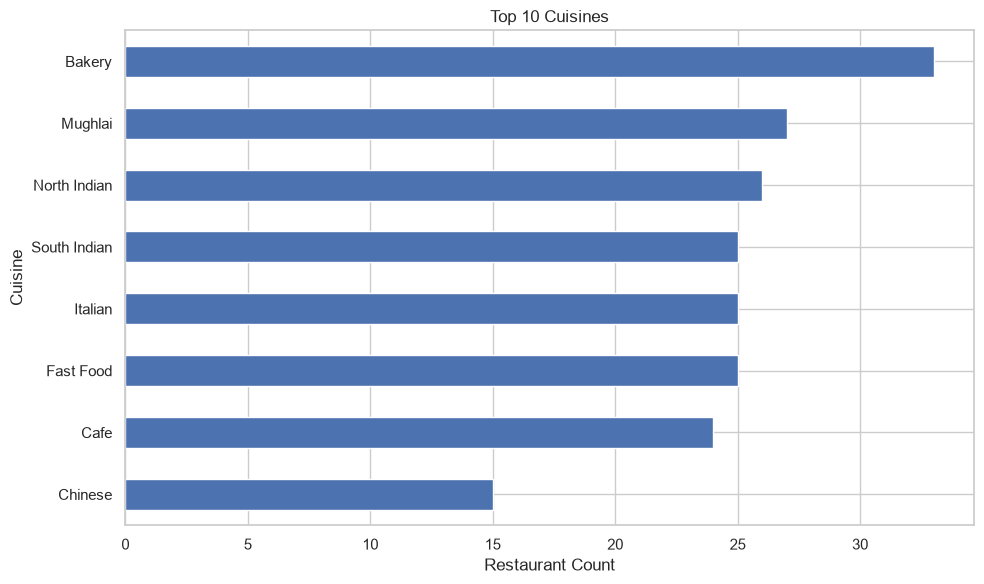

In [19]:
if 'Cuisines' in df.columns:
    cuisine_counts = (
        df['Cuisines']
        .dropna()
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
    )

    print('Top 15 cuisines:')
    display(cuisine_counts.head(15).to_frame('Restaurant_Count'))

    plt.figure(figsize=(10, 6))
    cuisine_counts.head(10).sort_values().plot(kind='barh')
    plt.title('Top 10 Cuisines')
    plt.xlabel('Restaurant Count')
    plt.ylabel('Cuisine')
    plt.tight_layout()
    plt.show()

# TASK 3: GEOSPATIAL ANALYSIS

In [20]:
print('=' * 60)
print('LEVEL 1 - TASK 3: GEOSPATIAL ANALYSIS')
print('=' * 60)

if {'Latitude', 'Longitude'}.issubset(df.columns):
    geo = df[['Latitude', 'Longitude']].copy()

    print('Latitude summary:')
    display(geo['Latitude'].describe().to_frame())

    print('Longitude summary:')
    display(geo['Longitude'].describe().to_frame())

LEVEL 1 - TASK 3: GEOSPATIAL ANALYSIS
Latitude summary:


,Latitude
count,200.000000
mean,23.547643
std,2.981456
min,18.555384
25%,20.856582
50%,23.647545
75%,26.081828
max,28.690868


Longitude summary:


,Longitude
count,200.000000
mean,80.637804
std,4.527797
min,72.993152
25%,76.516571
50%,80.735221
75%,84.834409
max,88.290115


### 13. Geographical Distribution Scatter Plot

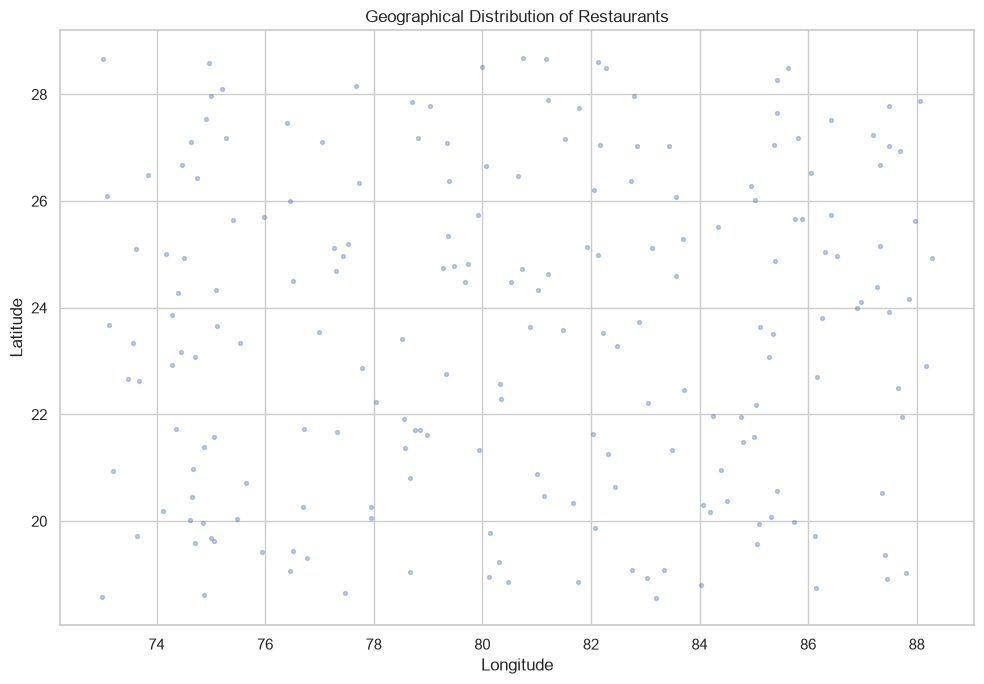

In [21]:
if {'Latitude', 'Longitude'}.issubset(df.columns):
    plt.figure(figsize=(10, 7))
    plt.scatter(
        df['Longitude'],
        df['Latitude'],
        s=8,
        alpha=0.35
    )
    plt.title('Geographical Distribution of Restaurants')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

### 14. Interactive Restaurant Map

In [22]:
if {'Latitude', 'Longitude'}.issubset(df.columns):
    if folium is not None:
        sample = df.dropna(subset=['Latitude', 'Longitude']).copy()
        sample = sample.sample(min(2000, len(sample)), random_state=42)

        center = [
            sample['Latitude'].mean(),
            sample['Longitude'].mean()
        ]

        restaurant_map = folium.Map(location=center, zoom_start=2)

        for _, row in sample.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=2,
                popup=str(row.get('Restaurant_Name', 'Restaurant')),
                fill=True
            ).add_to(restaurant_map)

        display(restaurant_map)
        restaurant_map.save('restaurant_locations.html')
        print('Interactive map saved as: restaurant_locations.html')
    else:
        print('Install folium for the interactive map: %pip install folium')

Interactive map saved as: restaurant_locations.html


### 15. Location vs Rating Analysis

In [23]:
if {'City', 'Aggregate_rating'}.issubset(df.columns):
    city_rating = (
        df.groupby('City')['Aggregate_rating']
        .agg(['count', 'mean'])
        .sort_values('count', ascending=False)
    )

    print('Average rating for cities with at least 50 restaurants:')
    display(
        city_rating[city_rating['count'] >= 50]
        .sort_values('mean', ascending=False)
        .head(15)
    )

if {'Country_Code', 'Aggregate_rating'}.issubset(df.columns):
    country_rating = (
        df.groupby('Country_Code')['Aggregate_rating']
        .agg(['count', 'mean'])
        .sort_values('count', ascending=False)
    )

    print('Average rating by country (minimum 20 restaurants):')
    display(
        country_rating[country_rating['count'] >= 20]
        .sort_values('mean', ascending=False)
    )

# Conclusion

The notebook completed the three Level 1 tasks:
- **Task 1:** Explored the dataset, standardized columns, converted numeric fields, removed duplicates, and handled missing values.
- **Task 2:** Performed descriptive analysis for numerical variables, countries, cities, and cuisines.
- **Task 3:** Analyzed restaurant coordinates, visualized geographical distribution, created an interactive map, and compared ratings by location.

## Final Status
**LEVEL 1 - TASKS 1, 2 AND 3 COMPLETE**